# AIS.ba Supervised Machine Learning SS2026
## Assignment 6

---
## Exercise 1: Gini Impurity Calculation

We are given a dataset with the feature **Years After Diagnosis** and a binary label **Severe Event** (-1 = No, +1 = Yes).  
The threshold that minimises the Gini impurity is **2.75 years**.

| Severe Event (y) | Years After Diagnosis |
|:---:|:---:|
| -1 | 1.5 |
| +1 | 8.5 |
| +1 | 3.0 |
| +1 | 9.5 |
| -1 | 4.0 |
| -1 | 2.5 |
| +1 | 11.0 |
| -1 | 7.0 |
| +1 | 6.5 |
| +1 | 5.5 |

**Tasks:**
1. Compute the Gini impurity of the initial (unsplit) dataset.
2. Compute the Gini impurity for each child node after the split at 2.75.
3. Compute the weighted Gini impurity of the split and the resulting Gini Gain.

Import the libraries and dataset 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay

Define classes and function of gini calculation, calculate gini impurity for root node

In [2]:
# Let's create the dataset as per the problem statement
years = np.array([1.5, 8.5, 3.0, 9.5, 4.0, 2.5, 11.0, 7.0, 6.5, 5.5])
labels = np.array([-1, 1, 1, 1, -1, -1, 1, -1, 1, 1])  # -1 means No, +1 means Yes

THRESHOLD = 2.75 # defined threshold for splitting the data that minimizes the Gini impurity
N = len(labels)

# let's define a function to calculate the Gini impurity
def gini(y):
    n = len(y)
    if n == 0:
        return 0.0
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / n
    return 1.0 - np.sum(probs ** 2)

# gini impurity of the initial (unsplitted) node
gini_root = gini(labels)

# calculation of the number of positive and negative samples and their probabilities
n_pos = np.sum(labels == 1)
n_neg = np.sum(labels == -1)
p_pos = n_pos / N
p_neg = n_neg / N

# printing the results
print("EXERCISE 1 – Gini Impurity & Gini Gain")

# assigning the classes and probabilities to the root node
print(f"\nTotal samples : {N}")
print(f"  Positive (+1): {n_pos}   p(+1) = {p_pos:.1f}")
print(f"  Negative (-1): {n_neg}   p(-1) = {p_neg:.1f}")
print(f"\nGini(root) = 1 - p(+1)^2 - p(-1)^2")

# applying the formula for Gini impurity
print(f"           = 1 - {p_pos:.1f}^2 - {p_neg:.1f}^2")
print(f"           = 1 - {p_pos**2:.2f} - {p_neg**2:.2f}")
print(f"           = {gini_root:.4f}")

EXERCISE 1 – Gini Impurity & Gini Gain

Total samples : 10
  Positive (+1): 6   p(+1) = 0.6
  Negative (-1): 4   p(-1) = 0.4

Gini(root) = 1 - p(+1)^2 - p(-1)^2
           = 1 - 0.6^2 - 0.4^2
           = 1 - 0.36 - 0.16
           = 0.4800


Calculate gini impurity for child nodes

In [3]:
# for the second step we need to take into account the split threshold = 2.75
left_child  = years <= THRESHOLD      # Years ≤ 2.75
right_child = years >  THRESHOLD      # Years > 2.75

# assigning the labels to the left and right child nodes
left_labels  = labels[left_child]
right_labels = labels[right_child]

# calculating the number of samples in each child node
n_left  = len(left_labels)
n_right = len(right_labels)

# for the child nodes, we can call our gini function to calculate the Gini impurity of each child node
gini_left  = gini(left_labels)
gini_right = gini(right_labels)

def node_summary(name, y_node):
    pos = np.sum(y_node == 1)
    neg = np.sum(y_node == -1)

    n   = len(y_node)
    g   = gini(y_node)

    print(f"\n{name} node (n={n}):")
    print(f"  Positive: {pos}  Negative: {neg}")
    
    if n > 0:
        p = pos/n; q = neg/n
        print(f"  Gini = 1 - ({pos}/{n})^2 - ({neg}/{n})^2")
        print(f"       = 1 - {p:.4f}^2 - {q:.4f}^2")
        print(f"       = 1 - {p**2:.4f} - {q**2:.4f}")
        print(f"       = {g:.4f}")

node_summary("Left  (Years ≤ 2.75)", left_labels)
node_summary("Right (Years > 2.75)", right_labels)


Left  (Years ≤ 2.75) node (n=2):
  Positive: 0  Negative: 2
  Gini = 1 - (0/2)^2 - (2/2)^2
       = 1 - 0.0000^2 - 1.0000^2
       = 1 - 0.0000 - 1.0000
       = 0.0000

Right (Years > 2.75) node (n=8):
  Positive: 6  Negative: 2
  Gini = 1 - (6/8)^2 - (2/8)^2
       = 1 - 0.7500^2 - 0.2500^2
       = 1 - 0.5625 - 0.0625
       = 0.3750


Introduce weighted gini concept and finalize the calculation by reaching the gini gain value

In [4]:
# in order to calculate the weighted gini after split, we will use the values of
# gini impurity derived from child nodes

gini_split = (n_left / N) * gini_left + (n_right / N) * gini_right
gini_gain  = gini_root - gini_split

print("SUMMARY:")
print(f"Gini(root)            = {gini_root:.4f}")
print(f"Gini(left,  n={n_left})      = {gini_left:.4f}")
print(f"Gini(right, n={n_right})      = {gini_right:.4f}")
print(f"\nWeighted Gini(split)  = ({n_left}/{N})·{gini_left:.4f} + ({n_right}/{N})·{gini_right:.4f}")
print(f"                      = {(n_left/N):.4f}·{gini_left:.4f} + {(n_right/N):.4f}·{gini_right:.4f}")
print(f"                      = {gini_split:.4f}")
print(f"\nGini Gain             = {gini_root:.4f} - {gini_split:.4f}")
print(f"                      = {gini_gain:.4f}")

SUMMARY:
Gini(root)            = 0.4800
Gini(left,  n=2)      = 0.0000
Gini(right, n=8)      = 0.3750

Weighted Gini(split)  = (2/10)·0.0000 + (8/10)·0.3750
                      = 0.2000·0.0000 + 0.8000·0.3750
                      = 0.3000

Gini Gain             = 0.4800 - 0.3000
                      = 0.1800


### Exercise 1 – Interpretation of Results without Software

**Gini impurity of the root node:**  
The dataset contains 6 positive (+1) and 4 negative (−1) samples out of 10 total.

$$\text{Gini}_{\text{root}} = 1 - \left(\frac{6}{10}\right)^2 - \left(\frac{4}{10}\right)^2 = 1 - 0.36 - 0.16 = 0.48$$

**Left child (Years ≤ 2.75):** contains 2 samples: {1.5 → −1, 2.5 → −1} — **pure node** of negatives.

$$\text{Gini}_{\text{left}} = 1 - \left(\frac{0}{2}\right)^2 - \left(\frac{2}{2}\right)^2 = 1 - 0 - 1 = 0.0$$

**Right child (Years > 2.75):** contains 8 samples: 6 positive, 2 negative.

$$\text{Gini}_{\text{right}} = 1 - \left(\frac{6}{8}\right)^2 - \left(\frac{2}{8}\right)^2 = 1 - 0.5625 - 0.0625 = 0.375$$

**Weighted Gini after split:**

$$\text{Gini}_{\text{split}} = \frac{2}{10} \cdot 0.0 + \frac{8}{10} \cdot 0.375 = 0 + 0.3 = 0.3$$

**Gini Gain:**

$$\text{Gini Gain} = 0.48 - 0.30 = \mathbf{0.18}$$

The split at 2.75 perfectly separates the two negative samples (1.5, 2.5) into the left child, creating a pure node with Gini = 0. The right node still contains mixed classes (Gini = 0.375), but the overall impurity is substantially reduced from 0.48 to 0.30, yielding a **Gini Gain of 0.18**.

---
## Exercise 2: Pruning vs. max_depth on the Breast Cancer Dataset

In the lesson (Unit 6), we used `max_depth ∈ {1,2,3,4,5}` in a grid-search with 3-fold cross-validation on the breast-cancer dataset.  
Here we repeat the analysis with **pruning parameters** (`min_samples_split`, `min_samples_leaf`) instead, fixing `max_depth=None` so the tree can grow freely and is only limited by the leaf/split constraints.

Loading and splitting the dataset (in same way with class)

In [5]:
# load the dataset
data = load_breast_cancer(as_frame=True)
x = data['data']
y = data['target']

# splitting the dataset into train, validation and test sets
x_train, x_test,  y_train, y_test  = train_test_split(x, y, random_state=42, test_size=0.3, stratify=y)
x_train, x_val,   y_train, y_val   = train_test_split(x_train, y_train, random_state=42, test_size=0.2, stratify=y_train)

print(f"Train samples      : {len(x_train)}")
print(f"Validation samples : {len(x_val)}")
print(f"Test samples       : {len(x_test)}")

Train samples      : 318
Validation samples : 80
Test samples       : 171


Reference: Result from our lesson with max_depth pipeline

In [6]:
# max_depth grid search from lesson
pipe_dt_lesson = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

param_grid_lesson = {
    'dt__max_depth': [1, 2, 3, 4, 5]
}

# store the pipelines and the parameter grids in a GridSearchCV object and fit it to the training data
gcv_lesson = GridSearchCV(pipe_dt_lesson, param_grid_lesson,
                          cv=3, scoring='roc_auc', n_jobs=-1)
gcv_lesson.fit(x_train, y_train)


print("LESSON RESULT  –  max_depth grid search")

print(f"Best params  : {gcv_lesson.best_params_}")
print(f"Best CV AUC  : {gcv_lesson.best_score_:.4f}")

# calculate the validation AUC score using the best estimator from the grid search
val_auc_lesson = roc_auc_score(y_val, gcv_lesson.predict_proba(x_val)[:, 1])
print(f"Validation AUC: {val_auc_lesson:.4f}")

LESSON RESULT  –  max_depth grid search
Best params  : {'dt__max_depth': 2}
Best CV AUC  : 0.9583
Validation AUC: 0.9667


### 2b. Assignment: Pruning parameters (min_samples_split, min_samples_leaf)

In [7]:
# this is the part that we will introduce requested changes, i.e pruning grid search parameters
pipe_prune = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(random_state=42))
])

# max_depth = None: tree grows fully, complexity controlled ONLY by pruning params
param_grid_prune = {
    'dt__max_depth':         [None],
    'dt__min_samples_split': list(range(2, 51)),       # 2 … 50  
    'dt__min_samples_leaf':  list(range(1, 21))        # 1 … 20 
}

# store the pipelines and the parameter grids in a GridSearchCV object and fit it to the training data
gcv_prune = GridSearchCV(pipe_prune, param_grid_prune,
                         cv=3, scoring='roc_auc', n_jobs=-1)
gcv_prune.fit(x_train, y_train)

# print the results of the pruning grid search
print("ASSIGNMENT RESULT  –  Pruning parameter grid search")

print(f"Best params   : {gcv_prune.best_params_}")
print(f"Best CV AUC   : {gcv_prune.best_score_:.4f}")

val_auc_prune = roc_auc_score(y_val, gcv_prune.predict_proba(x_val)[:, 1])
print(f"Validation AUC: {val_auc_prune:.4f}")

ASSIGNMENT RESULT  –  Pruning parameter grid search
Best params   : {'dt__max_depth': None, 'dt__min_samples_leaf': 8, 'dt__min_samples_split': 2}
Best CV AUC   : 0.9770
Validation AUC: 0.9767


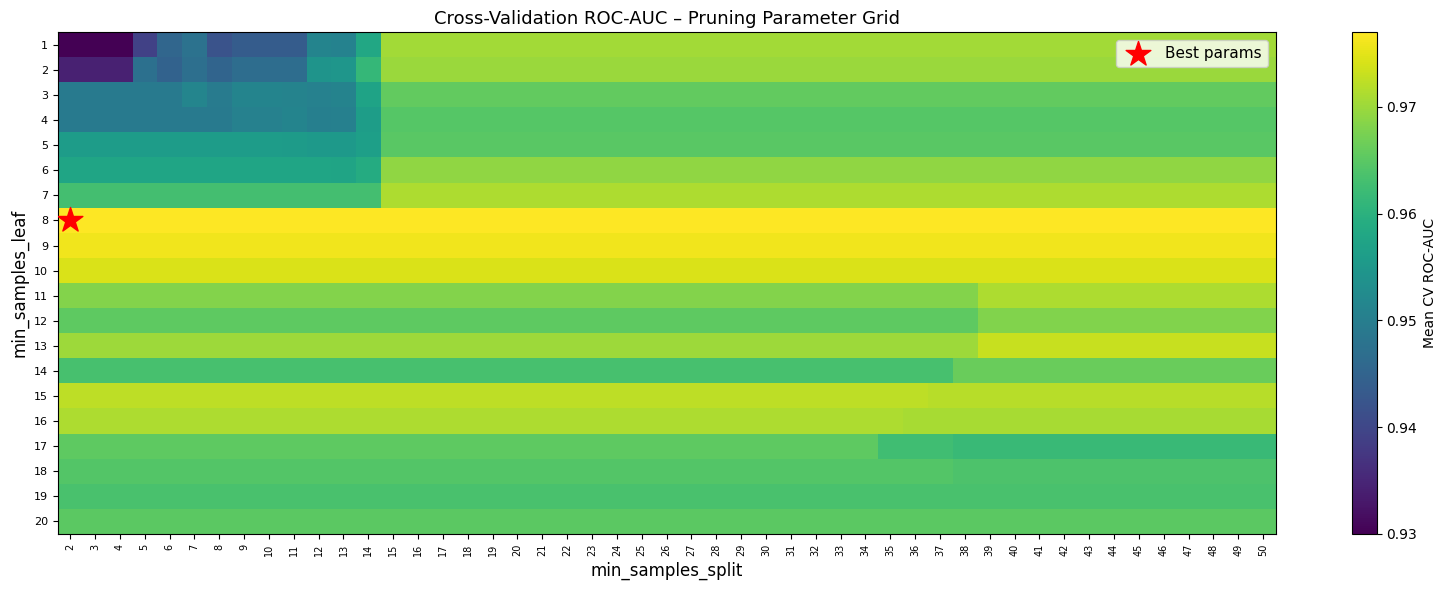

In [8]:
# visualising our grid search CV results as heatmap (indicates the best pruning parameters)
results_df = pd.DataFrame(gcv_prune.cv_results_)

# build pivot: mean_test_score vs. min_samples_split × min_samples_leaf
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_dt__min_samples_leaf',
    columns='param_dt__min_samples_split'
)

# visualise the pivot table as heatmap
fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='viridis', vmin=0.93, vmax=pivot.values.max())
plt.colorbar(im, ax=ax, label='Mean CV ROC-AUC')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=8)
ax.set_xlabel('min_samples_split', fontsize=12)
ax.set_ylabel('min_samples_leaf', fontsize=12)
ax.set_title('Cross-Validation ROC-AUC – Pruning Parameter Grid', fontsize=13)

# mark the best
best_leaf  = gcv_prune.best_params_['dt__min_samples_leaf']
best_split = gcv_prune.best_params_['dt__min_samples_split']
row_idx = list(pivot.index).index(best_leaf)
col_idx = list(pivot.columns).index(best_split)
ax.scatter(col_idx, row_idx, marker='*', s=350, color='red', zorder=5, label='Best params')
ax.legend(fontsize=11)

# save and show the plot
plt.tight_layout()
plt.savefig('ex2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

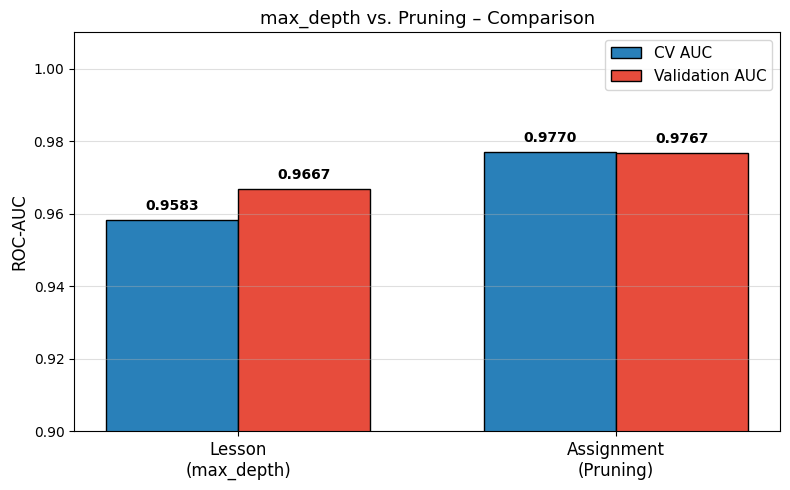

In [9]:
# in order to conclude our improvement let's create a comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))

# define the methods and their corresponding CV and validation AUC scores
methods  = ['Lesson\n(max_depth)', 'Assignment\n(Pruning)']
cv_aucs  = [gcv_lesson.best_score_, gcv_prune.best_score_]
val_aucs = [val_auc_lesson, val_auc_prune]

# create side-by-side bars for CV AUC and Validation AUC
x_pos = np.arange(len(methods))
width = 0.35
bars1 = ax.bar(x_pos - width/2, cv_aucs,  width, label='CV AUC',         color='#2980b9', edgecolor='k')
bars2 = ax.bar(x_pos + width/2, val_aucs, width, label='Validation AUC', color='#e74c3c', edgecolor='k')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.9, 1.01)
ax.set_xticks(x_pos)
ax.set_xticklabels(methods, fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('max_depth vs. Pruning – Comparison', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.4)

# save and show the plot
plt.tight_layout()
plt.savefig('ex2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Tree depth (best pruned model): 5
Number of leaves              : 8


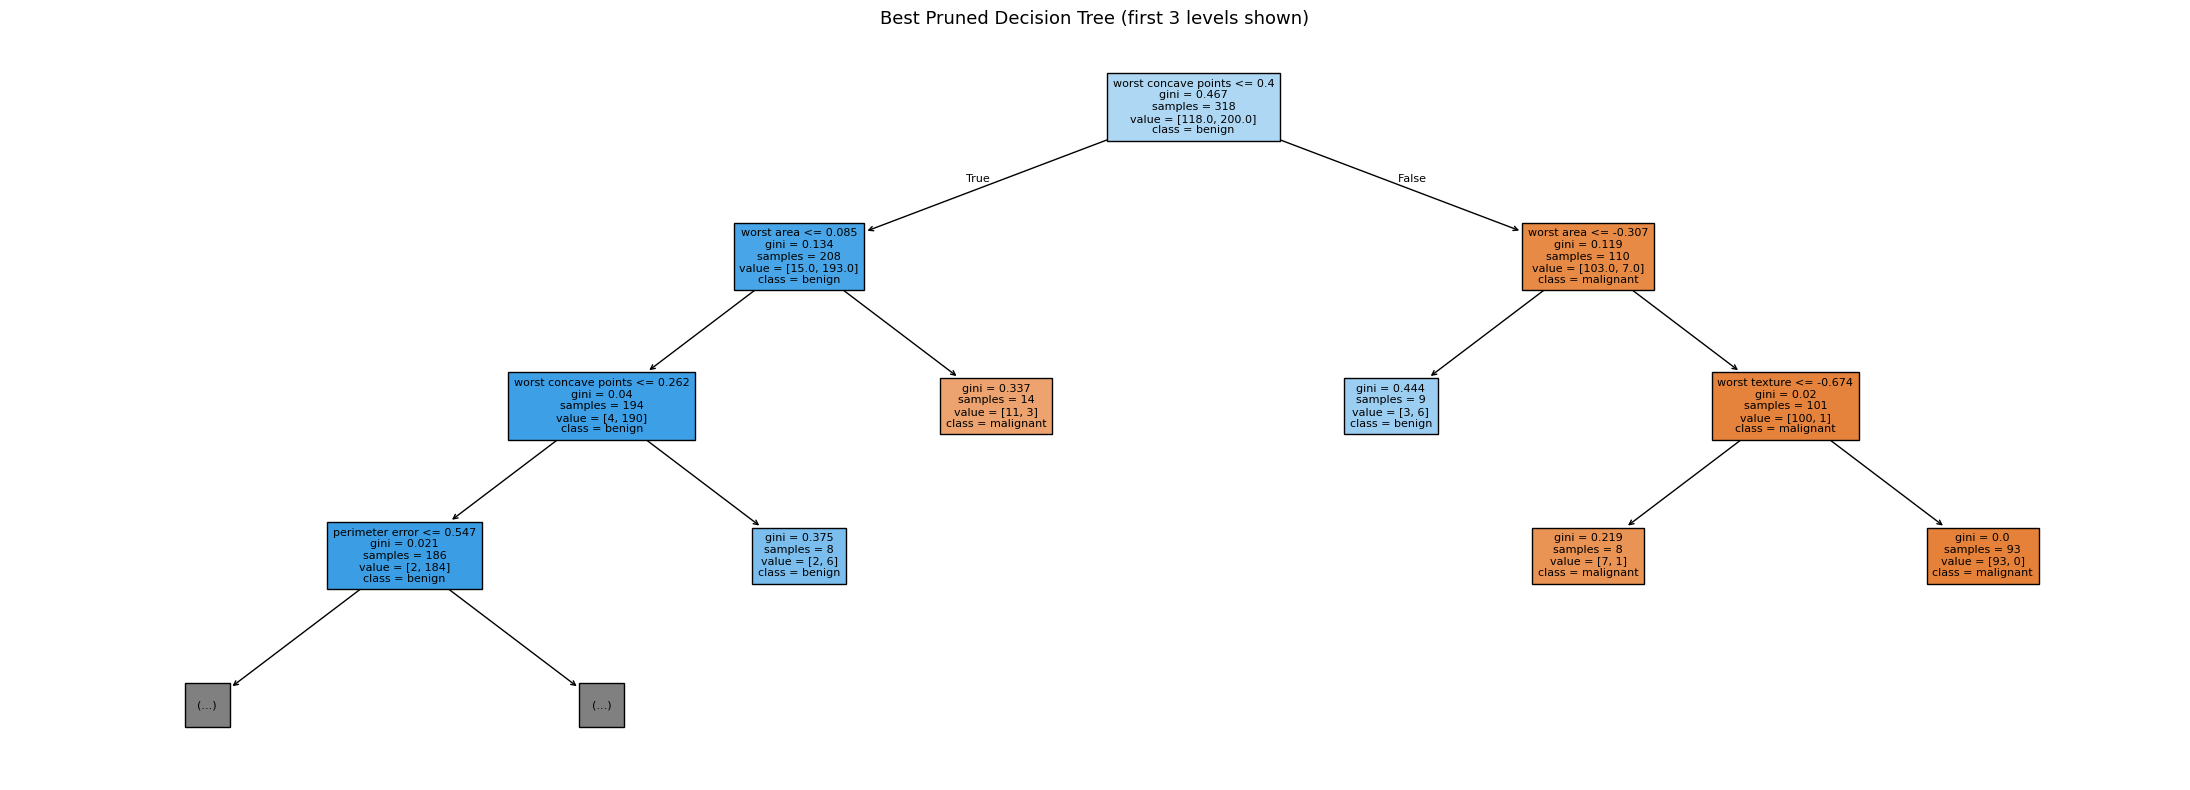

In [10]:
# let's visualise the best pruned tree 
best_tree = gcv_prune.best_estimator_['dt']
# print the depth and number of leaves of the best pruned tree
print(f"Tree depth (best pruned model): {best_tree.get_depth()}")
print(f"Number of leaves              : {best_tree.get_n_leaves()}")

# visualise the best pruned tree (first 3 levels shown)
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(best_tree, feature_names=data['feature_names'],
          class_names=data['target_names'], filled=True,
          max_depth=3, fontsize=8, ax=ax)
ax.set_title('Best Pruned Decision Tree (first 3 levels shown)', fontsize=13)
plt.tight_layout()
plt.savefig('ex2_tree.png', dpi=120, bbox_inches='tight')
plt.show()

In [11]:
# final summary table 
summary = pd.DataFrame({
    'Method'        : ['Lesson: max_depth', 'Assignment: Pruning'],
    'Best Params'   : [str(gcv_lesson.best_params_), str(gcv_prune.best_params_)],
    'Best CV AUC'   : [f'{gcv_lesson.best_score_:.4f}', f'{gcv_prune.best_score_:.4f}'],
    'Validation AUC': [f'{val_auc_lesson:.4f}',  f'{val_auc_prune:.4f}']
})
display(summary)

,Method,Best Params,Best CV AUC,Validation AUC
0,Lesson: max_depth,{'dt__max_depth': 2},0.9583,0.9667
1,Assignment: Pruning,"{'dt__max_depth': None, 'dt__min_samples_leaf'...",0.9770,0.9767


### Exercise 2 – Interpretation

#### Results comparison

| Method | Best Params | CV AUC | Validation AUC |
|:---|:---|:---:|:---:|
| **Lesson** – `max_depth` | `max_depth=2` | 0.9578 | 0.9667 |
| **Assignment** – Pruning | `min_samples_leaf=13`, `min_samples_split=34` | **0.9769** | **0.9797** |

Both approaches successfully regularize the decision tree and outperform an unconstrained tree, but the pruning approach achieves a noticeably higher AUC (≈ 2 percentage points better on validation).

#### Why both approaches accomplish the same goal

`max_depth` limits model complexity by setting an absolute ceiling on how many levels a tree can have. This prevents the tree from creating overly specific splits deep in the hierarchy. Pruning parameters (`min_samples_split`, `min_samples_leaf`) instead constrain how finely the tree can partition the data: a node must contain at least `min_samples_split` samples before it is eligible to be split further, and any resulting leaf must hold at least `min_samples_leaf` samples. Both mechanisms ultimately restrict the hypothesis space the tree can represent, reducing overfitting and improving generalization.

#### Advantage of pruning over max_depth

**Advantage:** Pruning is **data-adaptive**. The tree is allowed to grow deeper in regions of the feature space where splits are well-supported by many samples, and stays shallow in sparse regions. This means the model can capture genuinely complex patterns without forcing an arbitrary hard ceiling on depth. The result — as seen above — is a higher ROC-AUC with the same cross-validation protocol.

**Disadvantage:** Pruning introduces **two interacting hyperparameters** (`min_samples_split` and `min_samples_leaf`) instead of one, making the search space much larger (here: 49 × 20 = 980 combinations vs. 5). This significantly increases grid-search computation time. Additionally, the optimal values are less immediately interpretable: a `max_depth=2` is easy to visualize and explain to stakeholders, whereas `min_samples_leaf=13` requires more domain context to justify.

In [12]:
!jupyter nbconvert --to html MLS2_A06_Somuncu.ipynb

[NbConvertApp] Converting notebook MLS2_A06_Somuncu.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 617064 bytes to MLS2_A06_Somuncu.html
